In [2]:
import torch
import clip
from tqdm import tqdm
from PIL import Image
from torchvision.datasets import CIFAR100
import torchvision.transforms as transforms
import os

import numpy as np
from sklearn.linear_model import LogisticRegression
from torch.utils.data import DataLoader

from sklearn.neighbors import KernelDensity as KD
from sklearn.kernel_ridge import KernelRidge as KR
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import pairwise_kernels
from sklearn.metrics import accuracy_score, roc_auc_score,confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
import sys
sys.path.append('Level-Set-Boosting')
from sklearn.decomposition import PCA
from utils import grid_search_params
from MCBoost import MCBoost
from MAccWitness import MAccWitness

In [3]:
# for ARM Macs
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [4]:
def get_features(dataset):
    all_features = []
    all_labels = []
    ix = 0
    with torch.no_grad():
        # get image embeddings and labels
        for images, labels in tqdm(DataLoader(dataset, batch_size=200)):
            features = model.encode_image(images.to(device))

            all_features.append(features)
            all_labels.append(labels)

            ix += 200
    return torch.cat(all_features).cpu().numpy(), torch.cat(all_labels).cpu().numpy()

def get_text_features(classes):
    with torch.no_grad():
        # get text embeddings
        text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in classes]).to(device)
        text_features = model.encode_text(text_inputs)
    return text_features.cpu().numpy()

In [5]:
# Load CIFAR-100 test dataset
testset = CIFAR100(root='./data', train=False, download=True, transform=preprocess)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

dolphin_index = testset.class_to_idx['dolphin']
shark_index = testset.class_to_idx['shark']

# Iterate through the dataset and find a sample image of dolphin and shark
dolphin_imgs = []
shark_imgs = []
for images, labels in testloader:
    for i in range(len(labels)):
        if labels[i] == dolphin_index:
            dolphin_imgs.append(images[i])
        elif labels[i] == shark_index:
            shark_imgs.append(images[i])

# Denormalize and convert tensors to numpy arrays for visualization
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(100, 3, 224, 224)
(100, 3, 224, 224)
Sample Dolphin Image:


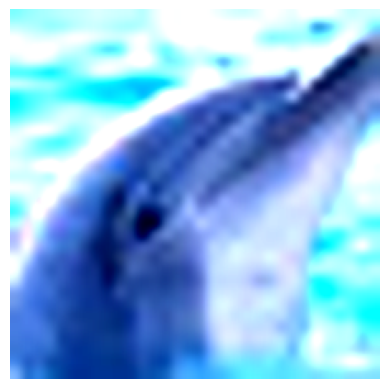

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Sample Shark Image:


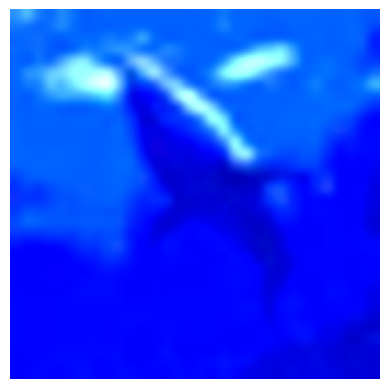

In [6]:
print(np.array(dolphin_imgs).shape)
print(np.array(shark_imgs).shape)
# Display a sample dolphin image
print('Sample Dolphin Image:')
imshow(dolphin_imgs[2])

# Display a sample shark image
print('Sample Shark Image:')
imshow(shark_imgs[2])


In [7]:
# split testset100 into validation and test
generator1 = torch.Generator().manual_seed(42)
testset = dolphin_imgs + shark_imgs
labels = [0]*len(dolphin_imgs) + [1]*len(shark_imgs)
testset = list(zip(testset, labels))
val_data, test_data = torch.utils.data.random_split(testset, [0.5, 0.5], generator=generator1)

val_embeddings, val_labels = get_features(val_data)
test_embeddings, test_labels = get_features(test_data)

100%|██████████| 1/1 [00:01<00:00,  1.07s/it]


In [8]:
print(val_embeddings.shape)
print(val_labels.shape)
print(test_embeddings.shape)
print(test_labels.shape)

(100, 512)
(100,)
(100, 512)
(100,)


### Zero Shot Prediction with CLIP

In [9]:
text_features = get_text_features(["dolphin", "shark"])
# prediction
val_embeddings /= torch.tensor(val_embeddings).norm(dim=-1, keepdim=True)
text_features /= torch.tensor(text_features).norm(dim=-1, keepdim=True)
similarity = (100.0 * val_embeddings @ text_features.T).clone().detach().softmax(dim=-1)   
val_values, val_labels_pred = similarity.topk(1)
val_labels_pred = val_labels_pred.numpy()
# Calculate the accuracy
correct_predictions = np.sum(val_labels_pred.squeeze() == val_labels)
total_predictions = len(val_labels)
accuracy = correct_predictions / total_predictions
accuracy_percentage = accuracy * 100
print("Validation Accuracy:", accuracy_percentage, "%")
# prediction on test set
test_embeddings /= torch.tensor(test_embeddings).norm(dim=-1, keepdim=True) 
similarity = (100.0 * test_embeddings @ text_features.T).clone().detach().softmax(dim=-1)  
test_values, test_labels_pred = similarity.topk(1)
test_labels_pred = test_labels_pred.numpy()

test_correct_predictions = np.sum(test_labels_pred.squeeze() == test_labels)
total_predictions = len(test_labels)
test_accuracy = test_correct_predictions / total_predictions
# Convert accuracy to a percentage
test_accuracy_percentage = test_accuracy * 100

print("Test Accuracy:", test_accuracy_percentage, "%")

# process into probability of label==1
for i in range(len(val_values)):
    if val_labels_pred[i] == 0:
        val_values[i] = 1 - val_values[i]
        
for i in range(len(test_values)):
    if test_labels_pred[i] == 0:
        test_values[i] = 1 - test_values[i]

val_probs = val_values.numpy().squeeze()
test_probs = test_values.numpy().squeeze()

Validation Accuracy: 81.0 %
Test Accuracy: 76.0 %


### Prototypes and Witness using Witness Function

In [10]:
import heapq

def top_k_indices(lst, k):
    """
    Returns the indices of the top k elements in the list.
    """
    return heapq.nlargest(k, range(len(lst)), lst.__getitem__)

def top_k_imgs(wit_values, k, orig_data, predicted_labels, show_imgs=False):
    """
    Prints the values in listA that correspond to the top k highest values in listB.
    """
    top_indices = top_k_indices(wit_values, k)
    count_error = 0
    for i in range(len(top_indices)):
        if predicted_labels[top_indices[i]] != orig_data[top_indices[i]][1]:
            count_error += 1
        if show_imgs:
            label = "dolphin" if orig_data[top_indices[i]][1] == 0 else "shark"
            predict_label = "dolphin" if predicted_labels[top_indices[i]] == 0 else "shark"
            print("correct label:", label, "\tpredicted label:",predict_label)
            imshow(test_data[top_indices[i]][0])
    return float(count_error)

def plot_percentage_error_over_sample(wit_values, img_data, correct_predictions, predicted_label, wit_take_abs = False, is_test_set = True, show_imgs=False):
    errors_explained = []
    total_error = len(wit_values) - correct_predictions
    if wit_take_abs:
        wit_values = np.abs(wit_values)
    for k in range(len(wit_values)):
        errors_explained.append(top_k_imgs(wit_values, k+1, img_data, predicted_label.squeeze(), show_imgs))

    # errors_explained/= total_error # percentage of error predicted
    # errors_explained *= 100
    # set x and y axis
    plt.xlabel('percentage of images selected')
    plt.ylabel('number of errors flagged')

    plt.plot(errors_explained, label = 'MAccWit')
    # add y=x line
    plt.plot([i for i in range(len(wit_values))], [i* total_error/(len(wit_values)) for i in range(len(wit_values))], 'r--', label='random guessing')
    if wit_take_abs:
        if is_test_set:
            plt.title('abs(MAccWit) on Test Set')
        else:
            plt.title('abs(MAccWit) on Validation Set')
    else:
        if is_test_set:
            plt.title('MAccWit on Test Set')
        else:
            plt.title('MAccWit on Validation Set')
    plt.legend()


In [18]:
# residuals of zero-shot model
# residuals in terms of 0-1 error
error_val = (val_labels_pred.squeeze() != val_labels).astype(int)
error_test = (test_labels_pred.squeeze() != test_labels).astype(int)

# residuals in terms of probabilities
# error_val = val_labels - val_probs
# error_test = test_labels - test_probs


In [19]:
print((val_embeddings).shape)

torch.Size([100, 512])


In [35]:
# reducing embedding dimension to 5 
pca = PCA(n_components=5)
# # try fitting on only error
# val_embeddings_error = val_embeddings[val_labels_pred.squeeze() != val_labels]
pca.fit(val_embeddings)
val_embeddings_pca = pca.transform(val_embeddings)
test_embeddings_pca = pca.transform(test_embeddings)

# training the witness function
witness_metric = 'rbf'

# search for optimal rbf kernel param using witness set
gopt = grid_search_params(witness_metric, val_embeddings_pca, error_val)

# define witness on witness set
wit = MAccWitness(gamma=gopt, metric=witness_metric)
wit_model = make_pipeline(StandardScaler(), wit)
wit_model.fit(val_embeddings_pca, error_val)

wit_test = wit_model.predict(test_embeddings_pca)
wit_val = wit_model.predict(val_embeddings_pca)

test_correct_predictions = np.sum(test_labels_pred.squeeze() == test_labels)
val_correct_predictions = np.sum(val_labels_pred.squeeze() == val_labels)

Optimal Gamma: 6.0


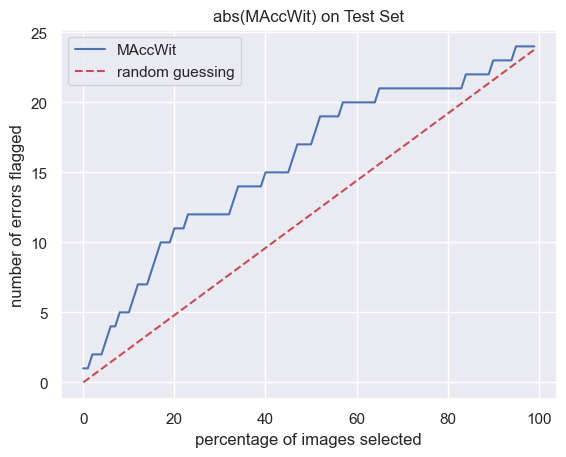

In [36]:
plot_percentage_error_over_sample(wit_test, test_data, test_correct_predictions, test_labels_pred, wit_take_abs = True, is_test_set = True)

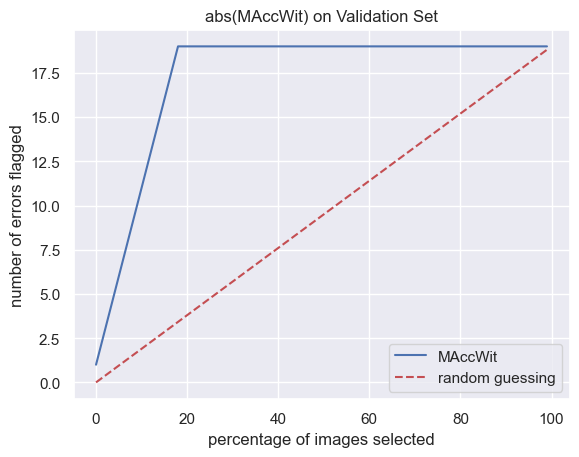

In [37]:
plot_percentage_error_over_sample(wit_val, val_data, val_correct_predictions, val_labels_pred, wit_take_abs = True, is_test_set = False)

wit_val: 0.191,0.393


(array([81.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 19.]),
 array([2.70790650e-31, 1.02528025e-01, 2.05056051e-01, 3.07584076e-01,
        4.10112101e-01, 5.12640126e-01, 6.15168152e-01, 7.17696177e-01,
        8.20224202e-01, 9.22752228e-01, 1.02528025e+00]),
 <BarContainer object of 10 artists>)

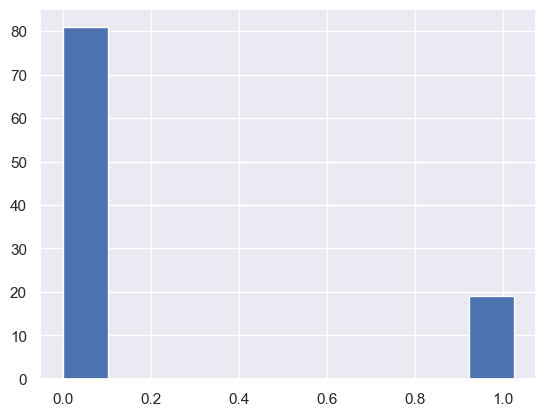

In [38]:
print(f"wit_val: {np.mean(wit_val):.3f},{np.std(wit_val):.3f}")
plt.hist(wit_val)

wit_test: 0.019,0.097


(array([97.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  1.]),
 array([1.02407202e-26, 8.19133297e-02, 1.63826659e-01, 2.45739989e-01,
        3.27653319e-01, 4.09566648e-01, 4.91479978e-01, 5.73393308e-01,
        6.55306637e-01, 7.37219967e-01, 8.19133297e-01]),
 <BarContainer object of 10 artists>)

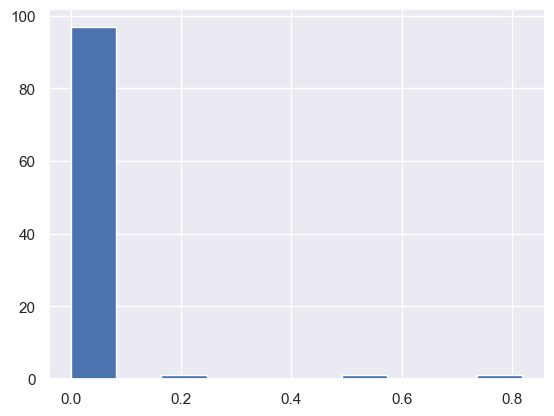

In [39]:
# print 3sf of mean and std

print(f"wit_test: {np.mean(wit_test):.3f},{np.std(wit_test):.3f}")
plt.hist(wit_test)

In [546]:
print(np.unique(wit_test))

[1.02702503e-26 1.72229986e-21 7.36482387e-18 1.22067445e-16
 2.44380975e-16 3.01956466e-16 1.34436639e-15 5.78565760e-15
 9.96310290e-15 9.46276447e-14 9.97804936e-14 7.89496474e-13
 1.37323853e-12 1.43605436e-12 3.19304980e-12 3.36753073e-12
 1.16182700e-11 3.59039154e-11 1.20633928e-10 2.27257633e-10
 2.56918391e-10 3.47523529e-09 5.91551988e-09 1.38626130e-08
 1.86769954e-08 1.99938459e-08 3.65196602e-08 4.97504639e-08
 5.38258135e-08 6.94464045e-08 1.34736012e-07 1.34927243e-07
 1.57418049e-07 1.62421932e-07 1.80699525e-07 3.82811177e-07
 4.21510538e-07 4.62134625e-07 6.76560431e-07 1.12410649e-06
 1.42055993e-06 3.87435160e-06 4.60697428e-06 5.86322522e-06
 7.47946951e-06 7.82706264e-06 8.90068956e-06 9.37754698e-06
 9.69850631e-06 1.03799168e-05 1.07884887e-05 2.32700678e-05
 2.52293865e-05 3.90629269e-05 4.10582137e-05 5.86972224e-05
 7.17793960e-05 9.16851893e-05 9.21978242e-05 1.03882111e-04
 1.15516332e-04 1.26294475e-04 1.90401924e-04 1.97073561e-04
 2.85259233e-04 3.128100

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Top 5 images flagged by MAccWit
correct label: shark 	predicted label: dolphin


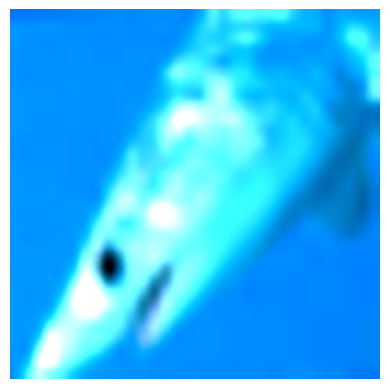

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


correct label: shark 	predicted label: shark


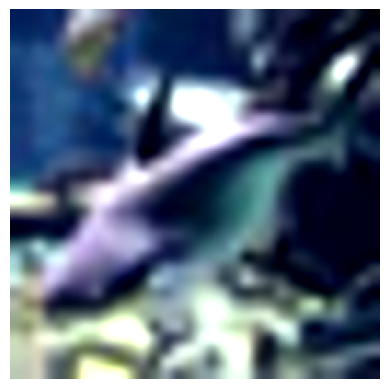

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


correct label: shark 	predicted label: dolphin


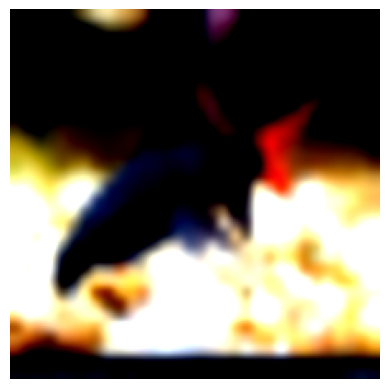

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


correct label: dolphin 	predicted label: dolphin


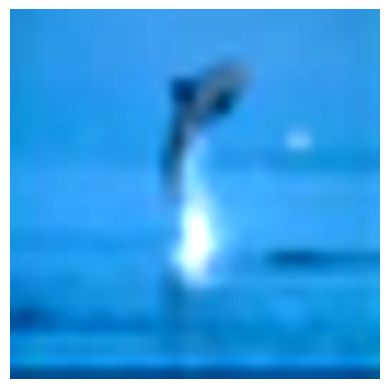

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


correct label: dolphin 	predicted label: dolphin


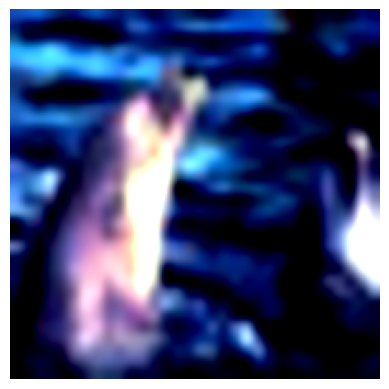

2.0

In [41]:
print("Top 5 images flagged by MAccWit")
top_k_imgs(abs(wit_test), 5, test_data, test_labels_pred.squeeze(), show_imgs=True)

### Try Kernel Regression

In [548]:
from sklearn.kernel_ridge import KernelRidge
krr = KernelRidge(alpha=1, kernel = "rbf")
krr.fit(val_embeddings_pca, error_val)

KernelRidge(kernel='rbf')

In [549]:
krr_test = krr.predict(test_embeddings_pca)
krr_wit = krr.predict(val_embeddings_pca)

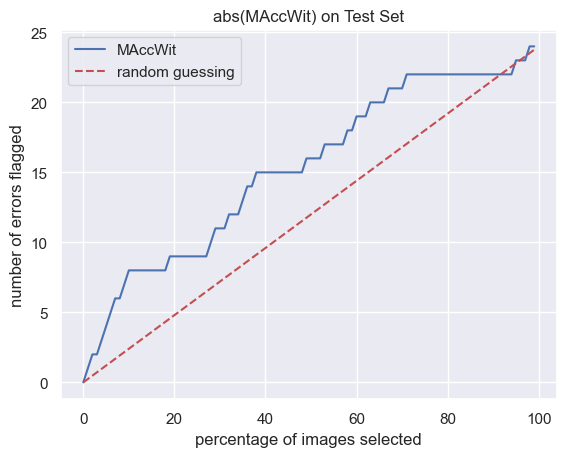

In [550]:
plot_percentage_error_over_sample(krr_test, test_data, test_correct_predictions, test_labels_pred, wit_take_abs = True, is_test_set = True)

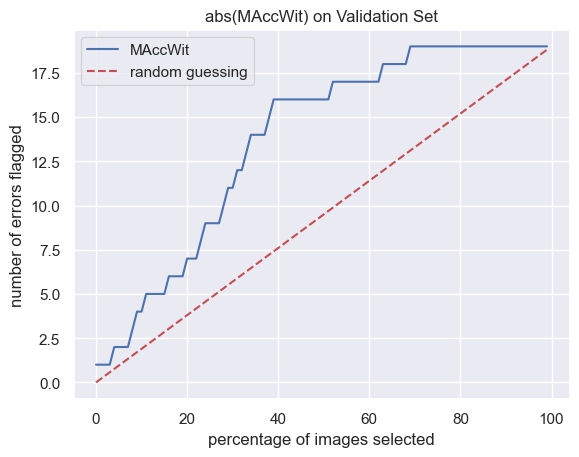

In [551]:
plot_percentage_error_over_sample(krr_wit, val_data, val_correct_predictions, val_labels_pred, wit_take_abs = True, is_test_set = False)